In [28]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Para mostrar el pipeline
from sklearn import set_config
from sklearn import datasets
set_config(display='diagram')
import matplotlib.pyplot as plt
sns.set()

In [3]:
dataset = datasets.load_breast_cancer()
print(dataset.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [4]:
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['class'] = dataset.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
dataset.target_names

array(['malignant', 'benign'], dtype='<U9')

<AxesSubplot:xlabel='class', ylabel='count'>

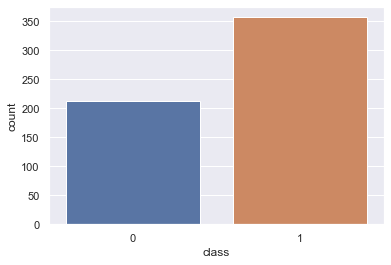

In [6]:
sns.countplot(data=df, x='class')

# Modelado base

In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


def calc_predictions(X_train, X_test, y_train, y_test):

    df_results = pd.DataFrame(columns=['model_name', 'accuracy', 'precision', 'recall_sensitivity', 'recall_specificity', 'f1', 'auc'])


    models = [
        LogisticRegression(max_iter=10000),
        KNeighborsClassifier(n_neighbors=11),
        SVC(),
        DecisionTreeClassifier(),
        RandomForestClassifier(n_estimators=50),
        AdaBoostClassifier(n_estimators=100),
        GradientBoostingClassifier(n_estimators=100)
    ]

    for model in models:
        # entrenamiento y predicciones
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # classification metrics
        model_name = model.__class__.__name__
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall_sensitivity = recall_score(y_test, y_pred)
        recall_specificity = recall_score(y_test, y_pred, pos_label=0)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

        # guardar resultados
        row = [model_name, accuracy, precision, recall_sensitivity, recall_specificity, f1, auc]
        df_results.loc[len(df_results)] = row

    return df_results

In [14]:
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
%%time
calc_predictions(X_train, X_test, y_train, y_test)

Wall time: 1.77 s


,model_name,accuracy,precision,recall_sensitivity,recall_specificity,f1,auc
0,LogisticRegression,0.965035,0.966667,0.977528,0.944444,0.972067,0.960986
1,KNeighborsClassifier,0.979021,0.977778,0.988764,0.962963,0.983240,0.975864
2,SVC,0.951049,0.936170,0.988764,0.888889,0.961749,0.938826
3,DecisionTreeClassifier,0.944056,0.976471,0.932584,0.962963,0.954023,0.947774
4,RandomForestClassifier,0.965035,0.966667,0.977528,0.944444,0.972067,0.960986
5,AdaBoostClassifier,0.944056,0.976471,0.932584,0.962963,0.954023,0.947774
6,GradientBoostingClassifier,0.958042,0.966292,0.966292,0.944444,0.966292,0.955368


# Escalado

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
%%time
calc_predictions(X_train_scaled, X_test_scaled, y_train, y_test)

Wall time: 953 ms


,model_name,accuracy,precision,recall_sensitivity,recall_specificity,f1,auc
0,LogisticRegression,0.979021,0.977778,0.988764,0.962963,0.983240,0.975864
1,KNeighborsClassifier,0.972028,0.977528,0.977528,0.962963,0.977528,0.970246
2,SVC,0.979021,0.977778,0.988764,0.962963,0.983240,0.975864
3,DecisionTreeClassifier,0.944056,0.965517,0.943820,0.944444,0.954545,0.944132
4,RandomForestClassifier,0.965035,0.966667,0.977528,0.944444,0.972067,0.960986
5,AdaBoostClassifier,0.944056,0.976471,0.932584,0.962963,0.954023,0.947774
6,GradientBoostingClassifier,0.958042,0.966292,0.966292,0.944444,0.966292,0.955368


# PCA

<AxesSubplot:>

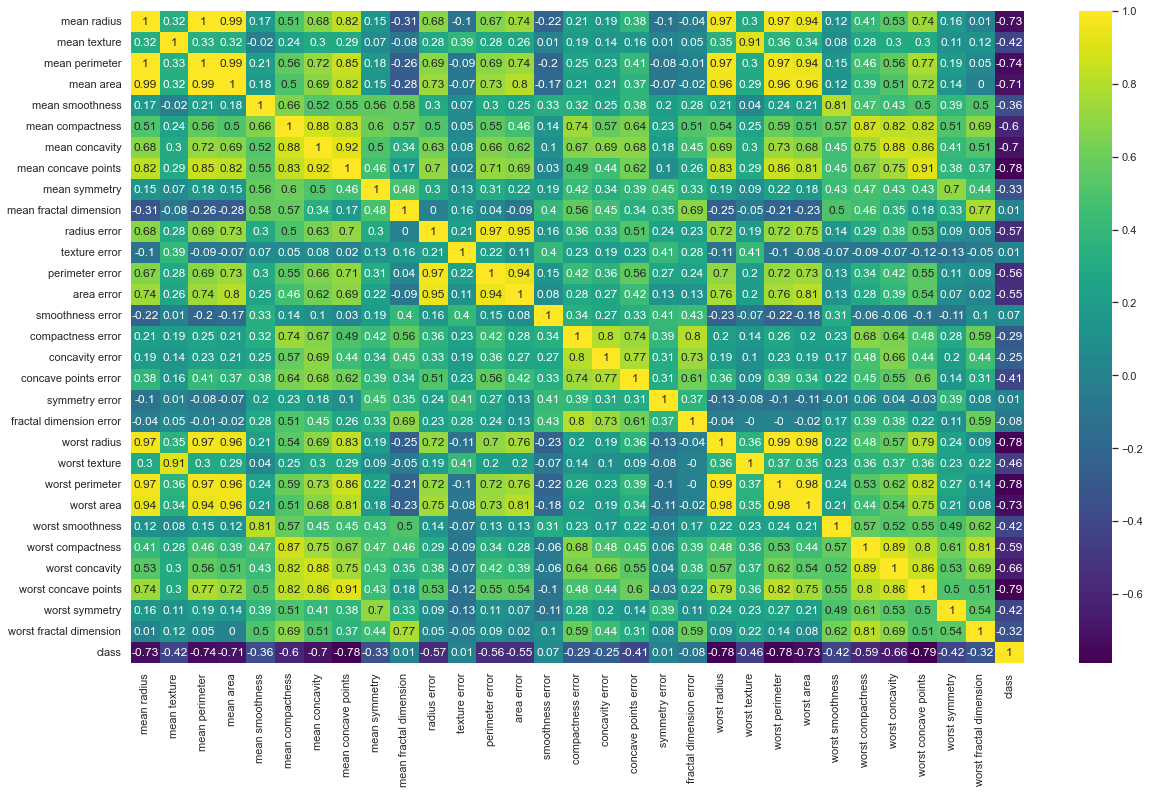

In [30]:
plt.figure(figsize=(20, 12))
sns.heatmap(df.corr().round(2), cmap='viridis', annot=True)

In [42]:
from sklearn.decomposition import PCA

# pca = PCA(n_components=.99)
pca = PCA(n_components=25)
pca.fit(X_train_scaled)

X_train_scaled_pca = pca.transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

In [43]:
X_train_scaled_pca.shape

(426, 25)

In [44]:
# varianza explicada por cada componente
print(pca.explained_variance_ratio_)

[5.18348559e-01 1.84112072e-01 7.00902687e-02 6.28725045e-02
 3.97301448e-02 3.29870609e-02 1.54073512e-02 1.32730368e-02
 1.05223023e-02 9.70247174e-03 8.74042023e-03 8.17899767e-03
 7.32102699e-03 4.33629163e-03 2.72530444e-03 2.32469741e-03
 1.75200053e-03 1.43411886e-03 1.38002723e-03 1.03711209e-03
 8.99530807e-04 8.06367330e-04 6.02164397e-04 4.90657824e-04
 3.67851794e-04]


In [45]:
# mismo que el anterior pero acumulando la suma:
print(np.cumsum(pca.explained_variance_ratio_))

[0.51834856 0.70246063 0.7725509  0.8354234  0.87515355 0.90814061
 0.92354796 0.936821   0.9473433  0.95704577 0.96578619 0.97396519
 0.98128622 0.98562251 0.98834781 0.99067251 0.99242451 0.99385863
 0.99523866 0.99627577 0.9971753  0.99798167 0.99858383 0.99907449
 0.99944234]


In [46]:
sum(pca.explained_variance_ratio_)

0.9994423403989997

Text(0, 0.5, 'explained_variance')

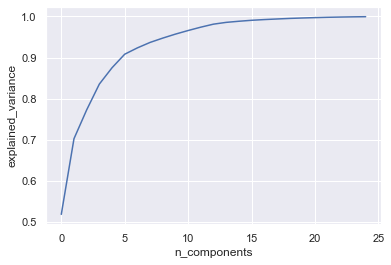

In [47]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("n_components")
plt.ylabel("explained_variance")

In [48]:
# viendo la gráfica podemos deducir que toda la varianza queda explicada con 10-12 componentes
pca = PCA(n_components=10)
pca.fit(X_train_scaled)

X_train_scaled_pca = pca.transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

In [49]:
%%time
# logramos el mismo resultado que el modelado base pero con 10 columnas en vez de 30, y en menos tiempo
calc_predictions(X_train_scaled_pca, X_test_scaled_pca, y_train, y_test)

Wall time: 680 ms


,model_name,accuracy,precision,recall_sensitivity,recall_specificity,f1,auc
0,LogisticRegression,0.979021,0.977778,0.988764,0.962963,0.983240,0.975864
1,KNeighborsClassifier,0.972028,0.977528,0.977528,0.962963,0.977528,0.970246
2,SVC,0.979021,0.977778,0.988764,0.962963,0.983240,0.975864
3,DecisionTreeClassifier,0.944056,0.976471,0.932584,0.962963,0.954023,0.947774
4,RandomForestClassifier,0.965035,0.977273,0.966292,0.962963,0.971751,0.964628
5,AdaBoostClassifier,0.958042,0.966292,0.966292,0.944444,0.966292,0.955368
6,GradientBoostingClassifier,0.972028,0.977528,0.977528,0.962963,0.977528,0.970246


In [53]:
print(pca.n_features_)
print(pca.n_components_)

30
10


In [54]:
# number of components
n_pcs= pca.components_.shape[0]

# get the index of the most important feature on EACH component i.e. largest absolute value
# using LIST COMPREHENSION HERE
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]

initial_feature_names = X.columns.values # columnas

# get the names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

# using LIST COMPREHENSION HERE AGAIN
dic = {i+1: most_important_names[i] for i in range(n_pcs)}

# build the dataframe
df = pd.DataFrame(sorted(dic.items()), columns=['PC', 'feature'])
df

,PC,feature
0,1,worst concave points
1,2,mean fractal dimension
2,3,symmetry error
3,4,worst texture
4,5,worst smoothness
5,6,worst symmetry
6,7,worst fractal dimension
7,8,mean symmetry
8,9,texture error
9,10,worst concavity


In [56]:
X_train_scaled_pca

array([[-0.64239154, -0.2869642 , -0.07838583, ...,  0.06887911,
         0.02997787, -0.00070865],
       [ 0.46413174,  0.38525073, -0.27283272, ..., -0.1088403 ,
         0.04002447,  0.04525244],
       [-0.34113621, -0.06345178,  0.1458204 , ..., -0.0462192 ,
        -0.03708743, -0.02291914],
       ...,
       [-0.67370933, -0.47880723, -0.03871123, ..., -0.04023294,
        -0.00544453, -0.03000875],
       [ 0.25289968,  0.14892849, -0.38280419, ...,  0.03906185,
         0.06363793, -0.01949404],
       [-0.51111414, -0.1951197 , -0.0556636 , ..., -0.09064093,
         0.04441462,  0.05195696]])

In [55]:
pd.DataFrame(X_train_scaled_pca, columns=most_important_names)

,worst concave points,mean fractal dimension,symmetry error,worst texture,worst smoothness,worst symmetry,worst fractal dimension,mean symmetry,texture error,worst concavity
0,-0.642392,-0.286964,-0.078386,-0.258853,0.245313,0.072088,0.015599,0.068879,0.029978,-0.000709
1,0.464132,0.385251,-0.272833,0.056580,-0.074652,0.013378,-0.018276,-0.108840,0.040024,0.045252
2,-0.341136,-0.063452,0.145820,0.045613,0.150675,0.296404,0.026192,-0.046219,-0.037087,-0.022919
3,0.691112,-0.183235,-0.275624,0.367223,0.112772,-0.051873,-0.064123,0.019694,0.091618,0.031562
4,0.743326,-0.484800,0.347832,-0.009856,0.039094,0.087670,-0.179588,0.144833,-0.031799,0.012785
...,...,...,...,...,...,...,...,...,...,...
421,-0.287414,0.886212,0.475994,-0.315709,0.303123,-0.252239,0.255755,-0.048445,-0.348234,-0.112431
422,-0.102457,0.294794,-0.136845,0.098844,-0.140079,-0.197087,-0.081119,0.023228,0.041942,0.050948
423,-0.673709,-0.478807,-0.038711,-0.074900,0.162487,0.140445,0.027130,-0.040233,-0.005445,-0.030009
424,0.252900,0.148928,-0.382804,0.096119,-0.020184,-0.095806,-0.017688,0.039062,0.063638,-0.019494
